# ExoScout v0.5 — Model Optimization and Final Evaluation

This notebook optimizes the Random Forest selected in the previous model comparison and evaluates the resulting frozen pipeline on the final holdout.

Hyperparameter tuning is performed exclusively on the development set using group-aware cross-validation. Different configurations are compared to determine whether controlling tree complexity, prediction stability, and diversity among the trees improves generalization.

The final holdout remains untouched during optimization. It will be evaluated only once, after the feature set, preprocessing pipeline, hyperparameters, selection metric, and classification threshold have been frozen.

## Evaluation Strategy

Random Forest hyperparameter configurations are compared using five-fold `StratifiedGroupKFold` cross-validation on the development set.

TIC ID (`tid`) remains the grouping variable, preventing TOIs associated with the same host star from appearing in both the training and validation portions of a fold.

Accuracy, precision, recall, and F1-score are recorded for every configuration. F1-score is defined in advance as the primary selection metric because it balances false positives and false negatives and remains consistent with the previous model comparisons.

The target definition, seven-feature input set, preprocessing pipeline, group-aware splitting strategy, and classification threshold of 0.5 remain unchanged.

After the best configuration has been selected, the complete procedure will be frozen. The selected pipeline will then be fitted on the full development set and evaluated once on the untouched final holdout. No modeling decision will be changed based on the holdout result.

In [1]:
import sys

from pathlib import Path

import pandas as pd

project_root = Path.cwd().parent

sys.path.append(str(project_root))

from src.load_data import load_data

df = load_data()

df.shape

(8113, 10)

## Data Preparation

The NASA TOI catalog is filtered to observations labeled as Confirmed Planets (`CP`), Known Planets (`KP`), or False Positives (`FP`).

`CP` and `KP` are mapped to the positive class (`1`), while `FP` is mapped to the negative class (`0`).

The same seven transit and stellar features used in the previous versions are retained. TIC ID (`tid`) is excluded from the predictive features and used only as a grouping variable.

Keeping the target definition and feature set unchanged ensures that any performance difference can be attributed to hyperparameter optimization rather than to a different dataset or input representation.

In [2]:
filtered_df = df[
    df["tfopwg_disp"].isin(["CP", "KP", "FP"])
].copy()

mapping = {
    "CP": 1,
    "KP": 1,
    "FP": 0
}

filtered_df["target"] = filtered_df["tfopwg_disp"].map(mapping)

In [3]:
features = [
    "pl_orbper",
    "pl_trandurh",
    "pl_trandep",
    "st_tmag",
    "st_teff",
    "st_logg",
    "st_rad"
]

X = filtered_df[features]

Y = filtered_df["target"]

groups = filtered_df["tid"]

In [4]:
X.shape, Y.shape, groups.shape

((2596, 7), (2596,), (2596,))

## Group-Aware Development and Holdout Split

The same group-aware development and final holdout split introduced in v0.3 is reconstructed with `random_state=42`.

The development set is used for hyperparameter optimization. The final holdout remains isolated until the selected pipeline has been frozen.

In [5]:
from sklearn.model_selection import StratifiedGroupKFold

holdout_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dev_idx, holdout_idx = next(
    holdout_splitter.split(
        X,
        Y,
        groups=groups
    )
)

X_dev = X.iloc[dev_idx].copy()
X_holdout = X.iloc[holdout_idx].copy()

Y_dev = Y.iloc[dev_idx].copy()
Y_holdout = Y.iloc[holdout_idx].copy()

groups_dev = groups.iloc[dev_idx].copy()
groups_holdout = groups.iloc[holdout_idx].copy()

In [6]:
shared_hosts = set(groups_dev).intersection(groups_holdout)

print("Development:", X_dev.shape)
print("Final holdout:", X_holdout.shape)
print("Shared hosts:", len(shared_hosts))

Development: (2077, 7)
Final holdout: (519, 7)
Shared hosts: 0


## Baseline Random Forest

The untuned Random Forest pipeline from v0.4 is reconstructed as the baseline for optimization.

Median imputation and missingness indicators remain inside the pipeline, ensuring that preprocessing is learned independently within each training fold.

The baseline configuration will be compared with the hyperparameter configurations using the same group-aware cross-validation folds and scoring metrics.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

random_forest_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42
        )
    )
])

In [8]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Baseline Cross-Validation

The default Random Forest is evaluated before optimization to establish a direct reference.

Both training and validation metrics are recorded. The difference between them helps determine whether the unrestricted trees fit the training folds substantially better than they generalize to unseen host stars.

In [9]:
from sklearn.model_selection import cross_validate

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_cv_results = cross_validate(
    estimator=random_forest_pipeline,
    X=X_dev,
    y=Y_dev,
    groups=groups_dev,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

In [10]:
baseline_summary = pd.DataFrame({
    "metric": scoring.keys(),
    "train_mean": [
        baseline_cv_results[f"train_{metric}"].mean()
        for metric in scoring
    ],
    "validation_mean": [
        baseline_cv_results[f"test_{metric}"].mean()
        for metric in scoring
    ],
    "validation_std": [
        baseline_cv_results[f"test_{metric}"].std()
        for metric in scoring
    ]
})

baseline_summary.round(3)

,metric,train_mean,validation_mean,validation_std
0,accuracy,1.0,0.822,0.011
1,precision,1.0,0.804,0.029
2,recall,1.0,0.871,0.032
3,f1,1.0,0.835,0.008


### Baseline Interpretation

The default Random Forest perfectly classifies the observations in its training folds, with all training metrics equal to 1.0.

Its mean validation F1-score is approximately 0.835, with a standard deviation of 0.008 across folds. The validation performance is therefore relatively stable, but the large difference between training and validation scores suggests that the unrestricted trees learn patterns that are more specific than necessary.

This does not prove that a more constrained forest will perform better. It provides the motivation for testing whether controlled tree complexity can reduce the train-validation gap without sacrificing validation performance.

## Hyperparameter Search Design

The search focuses on four Random Forest hyperparameters:

- `n_estimators` controls the number of trees and the stability of the aggregated prediction.
- `max_depth` limits the complexity of the decision paths.
- `min_samples_leaf` determines the minimum number of training observations supporting each leaf.
- `max_features` controls how many transformed features can be considered at each split and therefore influences diversity among the trees.

The search includes the default values as references as well as more constrained alternatives.

A randomized search is used to evaluate a controlled number of configurations rather than exhaustively testing every possible combination. Every sampled configuration is evaluated using the same five group-aware folds.

In [11]:
parameter_distributions = {
    "model__n_estimators": [
        100,
        300,
        500
    ],
    "model__max_depth": [
        None,
        5,
        10,
        20
    ],
    "model__min_samples_leaf": [
        1,
        2,
        5,
        10
    ],
    "model__max_features": [
        "sqrt",
        0.5,
        None
    ]
}

In [12]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=parameter_distributions,
    n_iter=40,
    scoring=scoring,
    refit="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

In [13]:
%%time

random_search.fit(
    X_dev,
    Y_dev,
    groups=groups_dev
);

Fitting 5 folds for each of 40 candidates, totalling 200 fits
CPU times: user 4.37 s, sys: 382 ms, total: 4.75 s
Wall time: 2min 40s


In [14]:
print(f"Best mean CV F1-score: {random_search.best_score_:.3f}")

random_search.best_params_

Best mean CV F1-score: 0.845


{'model__n_estimators': 500,
 'model__min_samples_leaf': 1,
 'model__max_features': 'sqrt',
 'model__max_depth': 20}

## Hyperparameter Search Results

The candidate configurations are ranked by their mean validation F1-score across the five group-aware folds.

Training F1-score is retained to assess the train–validation gap, while validation variability is examined to determine whether the leading result is stable across different groups of host stars.

In [15]:
search_results = pd.DataFrame(random_search.cv_results_)

top_search_results = (
    search_results[
        [
            "rank_test_f1",
            "mean_train_f1",
            "mean_test_f1",
            "std_test_f1",
            "mean_test_accuracy",
            "mean_test_precision",
            "mean_test_recall",
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__min_samples_leaf",
            "param_model__max_features"
        ]
    ]
    .sort_values("rank_test_f1")
    .head(10)
    .reset_index(drop=True)
)

top_search_results.round(3)

,rank_test_f1,mean_train_f1,mean_test_f1,std_test_f1,mean_test_accuracy,mean_test_precision,mean_test_recall,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,param_model__max_features
0,1,1.000,0.845,0.008,0.833,0.814,0.881,500,20,1,sqrt
1,2,0.985,0.845,0.011,0.833,0.813,0.882,300,None,2,sqrt
2,3,0.986,0.845,0.011,0.832,0.813,0.881,500,20,2,sqrt
3,4,0.958,0.844,0.011,0.828,0.797,0.899,300,10,1,sqrt
4,5,0.936,0.842,0.012,0.829,0.809,0.881,100,None,5,0.5
5,6,0.902,0.840,0.018,0.827,0.804,0.883,100,10,10,0.5
6,7,0.989,0.840,0.013,0.829,0.813,0.871,300,None,2,0.5
7,8,0.903,0.840,0.019,0.826,0.802,0.883,300,10,10,0.5
8,9,0.989,0.839,0.013,0.828,0.813,0.870,300,20,2,0.5
9,10,0.937,0.839,0.013,0.826,0.804,0.881,300,20,5,0.5


## Baseline and Optimized Model Comparison

The original and selected Random Forest pipelines are evaluated on the same group-aware folds to provide a direct comparison.

The comparison considers both validation performance and the training–validation gap. Hyperparameter optimization is considered useful only if it improves performance on unseen validation groups, not merely performance on the training observations.

In [16]:
comparison_rows = []

pipelines_to_compare = {
    "Baseline Random Forest": random_forest_pipeline,
    "Optimized Random Forest": random_search.best_estimator_
}

for model_name, pipeline in pipelines_to_compare.items():

    cv_results = cross_validate(
        pipeline,
        X_dev,
        Y_dev,
        groups=groups_dev,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    comparison_rows.append(
        {
            "model": model_name,
            "train_f1": cv_results["train_f1"].mean(),
            "validation_accuracy": cv_results["test_accuracy"].mean(),
            "validation_precision": cv_results["test_precision"].mean(),
            "validation_recall": cv_results["test_recall"].mean(),
            "validation_f1": cv_results["test_f1"].mean(),
            "validation_f1_std": cv_results["test_f1"].std()
        }
    )

optimization_comparison = pd.DataFrame(comparison_rows)

optimization_comparison.round(3)

,model,train_f1,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_f1_std
0,Baseline Random Forest,1.0,0.822,0.804,0.871,0.835,0.008
1,Optimized Random Forest,1.0,0.833,0.814,0.881,0.845,0.008


In [17]:
top_three_fold_results = (
    search_results[
        [
            "rank_test_f1",
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__min_samples_leaf",
            "param_model__max_features",
            "mean_train_f1",
            "mean_test_f1",
            "std_test_f1",
            "split0_test_f1",
            "split1_test_f1",
            "split2_test_f1",
            "split3_test_f1",
            "split4_test_f1"
        ]
    ]
    .sort_values("rank_test_f1")
    .head(3)
    .reset_index(drop=True)
)

top_three_fold_results.round(6)

,rank_test_f1,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,param_model__max_features,mean_train_f1,mean_test_f1,std_test_f1,split0_test_f1,split1_test_f1,split2_test_f1,split3_test_f1,split4_test_f1
0,1,500,20,1,sqrt,1.000000,0.845334,0.007967,0.842333,0.843823,0.834081,0.847966,0.858469
1,2,300,None,2,sqrt,0.985279,0.844956,0.011493,0.852814,0.827103,0.841871,0.841880,0.861111
2,3,500,20,2,sqrt,0.985625,0.844526,0.011170,0.848485,0.839161,0.827740,0.845494,0.861751


### Regularized Candidate Selection

The three leading configurations achieved practically equivalent mean validation F1-scores, with differences below one tenth of a percentage point and rankings that varied across folds.

The third-ranked configuration was selected as the provisional final candidate. Compared with the highest-ranked configuration, it increases `min_samples_leaf` from 1 to 2 while retaining 500 trees and a maximum depth of 20. This reduces mean training F1-score from 1.000 to 0.986 while sacrificing only 0.0008 mean validation F1.

This choice does not imply that the regularized configuration has been proven superior. It is a conservative tie-breaking decision made before inspecting the final holdout, favoring lower tree complexity when validation performance is practically indistinguishable.

In [18]:
selected_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=20,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42
            )
        )
    ]
)

selected_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",True
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Not

### Effective Tree Depth Check

Before using `max_depth=20` as a justification for selecting the third-ranked configuration, an unconstrained candidate with `min_samples_leaf=2` is fitted on one training fold.

The observed tree depths determine whether a limit of 20 would actively constrain the trees or merely represent an inactive hyperparameter.

In [19]:
from sklearn.base import clone
candidate_2_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42
            )
        )
    ]
)

first_train_indices, first_validation_indices = next(
    cv.split(
        X_dev,
        Y_dev,
        groups_dev
    )
)

candidate_2_fold_model = clone(candidate_2_pipeline)

candidate_2_fold_model.fit(
    X_dev.iloc[first_train_indices],
    Y_dev.iloc[first_train_indices]
)

unconstrained_forest = candidate_2_fold_model.named_steps["model"]

tree_depths = pd.Series(
    [
        tree.get_depth()
        for tree in unconstrained_forest.estimators_
    ],
    name="tree_depth"
)

print("Trees deeper than 20:", (tree_depths > 20).sum())
print("Share deeper than 20:", (tree_depths > 20).mean())
print("Maximum depth:", tree_depths.max())

tree_depths.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

Trees deeper than 20: 46
Share deeper than 20: 0.15333333333333332
Maximum depth: 28


count    300.000000
mean      18.370000
std        2.211198
min       13.000000
25%       17.000000
50%       18.000000
75%       20.000000
90%       21.000000
95%       22.000000
99%       24.000000
max       28.000000
Name: tree_depth, dtype: float64

The unconstrained candidate produced trees with a mean depth of 18.37 and a maximum depth of 28. Forty-six of its 300 trees, corresponding to 15.3% of the forest, exceeded a depth of 20.

Therefore, `max_depth=20` is an active constraint rather than a cosmetic parameter. The third-ranked configuration is retained as the provisional final candidate because it combines this depth limit with `min_samples_leaf=2`, while sacrificing only 0.0008 mean validation F1 relative to the highest-ranked configuration.

This remains a conservative tie-breaking decision, not evidence that the selected candidate will necessarily outperform the others on the final holdout.

In [20]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

selected_oof_probabilities = cross_val_predict(
    selected_pipeline,
    X_dev,
    Y_dev,
    groups=groups_dev,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

selected_oof_predictions = (
    selected_oof_probabilities >= 0.5
).astype(int)

classification_results = classification_report(
    Y_dev,
    selected_oof_predictions,
    target_names=[
        "catalog_false_positive",
        "planet"
    ],
    output_dict=True,
    zero_division=0
)

per_class_results = (
    pd.DataFrame(classification_results)
    .transpose()
    .loc[
        ["catalog_false_positive", "planet"],
        ["precision", "recall", "f1-score", "support"]
    ]
)

selected_confusion_matrix = pd.DataFrame(
    confusion_matrix(
        Y_dev,
        selected_oof_predictions
    ),
    index=[
        "actual_catalog_false_positive",
        "actual_planet"
    ],
    columns=[
        "predicted_catalog_false_positive",
        "predicted_planet"
    ]
)

print(per_class_results.round(3).to_string())

selected_confusion_matrix

                        precision  recall  f1-score  support
catalog_false_positive      0.860   0.781     0.818   1004.0
planet                      0.811   0.881     0.845   1073.0


,predicted_catalog_false_positive,predicted_planet
actual_catalog_false_positive,784,220
actual_planet,128,945


### Out-of-Fold Performance of the Selected Candidate

At the frozen threshold of 0.5, the selected candidate correctly identifies 945 of 1,073 planets and 784 of 1,004 catalog false positives.

Its out-of-fold planet recall is 0.881, while planet precision is 0.811. The model therefore remains more effective at recovering planets than at preventing catalog false positives from being classified as planets.

Compared with the untuned Random Forest, false positives decrease from 231 to 220 and false negatives decrease from 138 to 128, reducing the total number of out-of-fold errors from 369 to 348.

These predictions were generated exclusively within the development set using group-aware folds. They support the final model selection but do not replace the independent holdout evaluation.

## Final Pipeline Freeze

The selected pipeline is now frozen with:

- the original seven-feature input set;
- median imputation with missingness indicators;
- 500 Random Forest trees;
- maximum tree depth of 20;
- a minimum of two observations per leaf;
- square-root feature sampling at each split;
- `random_state=42`;
- a classification threshold of 0.5.

The pipeline is fitted on the complete development set. No feature, preprocessing step, hyperparameter, selection metric, or classification threshold will be changed after inspecting the final holdout results.

In [21]:
final_pipeline = clone(selected_pipeline)

final_pipeline.fit(
    X_dev,
    Y_dev
)

frozen_pipeline_summary = {
    "development_observations": len(X_dev),
    "features": features,
    "n_estimators": 500,
    "max_depth": 20,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "classification_threshold": 0.5
}

frozen_pipeline_summary

{'development_observations': 2077,
 'features': ['pl_orbper',
  'pl_trandurh',
  'pl_trandep',
  'st_tmag',
  'st_teff',
  'st_logg',
  'st_rad'],
 'n_estimators': 500,
 'max_depth': 20,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'classification_threshold': 0.5}

## Final Holdout Evaluation

The frozen pipeline is evaluated once on the untouched final holdout.

The holdout contains only host stars that were excluded from the development set. It has not contributed to feature selection, preprocessing decisions, model comparison, hyperparameter tuning, candidate selection, or threshold selection.

The following results provide the final independent estimate of the tabular pipeline's ability to generalize to TOIs associated with previously unseen host stars. No modeling decision will be changed in response to these results.

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

assert list(X_holdout.columns) == features
assert set(groups_dev).isdisjoint(set(groups_holdout))

classification_threshold = 0.5

holdout_planet_probabilities = final_pipeline.predict_proba(
    X_holdout
)[:, 1]

holdout_predictions = (
    holdout_planet_probabilities >= classification_threshold
).astype(int)

holdout_metrics = pd.DataFrame(
    [
        {
            "accuracy": accuracy_score(
                Y_holdout,
                holdout_predictions
            ),
            "precision": precision_score(
                Y_holdout,
                holdout_predictions
            ),
            "recall": recall_score(
                Y_holdout,
                holdout_predictions
            ),
            "f1_score": f1_score(
                Y_holdout,
                holdout_predictions
            )
        }
    ]
)

holdout_metrics.round(3)

,accuracy,precision,recall,f1_score
0,0.852,0.837,0.884,0.86


### Final Holdout Confusion Matrix and Per-Class Performance

The final predictions are examined by class to determine how many planets were recovered and how many catalog false positives were incorrectly promoted as planets.

This analysis describes the frozen model's behavior. It is not used to modify the pipeline or classification threshold.

In [23]:
holdout_classification_results = classification_report(
    Y_holdout,
    holdout_predictions,
    target_names=[
        "catalog_false_positive",
        "planet"
    ],
    output_dict=True,
    zero_division=0
)

holdout_per_class_results = (
    pd.DataFrame(holdout_classification_results)
    .transpose()
    .loc[
        ["catalog_false_positive", "planet"],
        ["precision", "recall", "f1-score", "support"]
    ]
)

holdout_confusion_matrix = pd.DataFrame(
    confusion_matrix(
        Y_holdout,
        holdout_predictions
    ),
    index=[
        "actual_catalog_false_positive",
        "actual_planet"
    ],
    columns=[
        "predicted_catalog_false_positive",
        "predicted_planet"
    ]
)

print(holdout_per_class_results.round(3).to_string())

holdout_confusion_matrix

                        precision  recall  f1-score  support
catalog_false_positive      0.869   0.817     0.842    251.0
planet                      0.837   0.884     0.860    268.0


,predicted_catalog_false_positive,predicted_planet
actual_catalog_false_positive,205,46
actual_planet,31,237


In [24]:
evaluation_summary = pd.DataFrame(
    [
        {
            "evaluation_set": "Development OOF",
            "observations": len(Y_dev),
            "accuracy": accuracy_score(
                Y_dev,
                selected_oof_predictions
            ),
            "precision": precision_score(
                Y_dev,
                selected_oof_predictions
            ),
            "recall": recall_score(
                Y_dev,
                selected_oof_predictions
            ),
            "f1_score": f1_score(
                Y_dev,
                selected_oof_predictions
            ),
            "false_positives": (
                (Y_dev == 0)
                & (selected_oof_predictions == 1)
            ).sum(),
            "false_negatives": (
                (Y_dev == 1)
                & (selected_oof_predictions == 0)
            ).sum()
        },
        {
            "evaluation_set": "Final holdout",
            "observations": len(Y_holdout),
            "accuracy": accuracy_score(
                Y_holdout,
                holdout_predictions
            ),
            "precision": precision_score(
                Y_holdout,
                holdout_predictions
            ),
            "recall": recall_score(
                Y_holdout,
                holdout_predictions
            ),
            "f1_score": f1_score(
                Y_holdout,
                holdout_predictions
            ),
            "false_positives": (
                (Y_holdout == 0)
                & (holdout_predictions == 1)
            ).sum(),
            "false_negatives": (
                (Y_holdout == 1)
                & (holdout_predictions == 0)
            ).sum()
        }
    ]
)

evaluation_summary.round(3)

,evaluation_set,observations,accuracy,precision,recall,f1_score,false_positives,false_negatives
0,Development OOF,2077,0.832,0.811,0.881,0.845,220,128
1,Final holdout,519,0.852,0.837,0.884,0.860,46,31


## Conclusion

ExoScout v0.5 optimized and finalized the Random Forest tabular classification pipeline without using the final holdout for model selection.

Hyperparameter optimization was performed exclusively on the development set using five-fold stratified group cross-validation. The three leading configurations produced practically equivalent validation F1-scores. A regularized configuration with 500 trees, a maximum depth of 20, `min_samples_leaf=2`, and square-root feature sampling was selected through a conservative tie-break decided before opening the holdout.

The selected pipeline achieved the following out-of-fold development performance:

- Accuracy: 0.832
- Precision: 0.811
- Recall: 0.881
- F1-score: 0.845

The pipeline was then fitted on the complete development set and evaluated once on the untouched final holdout, containing 519 TOIs associated with host stars not present in development. It achieved:

- Accuracy: 0.852
- Precision: 0.837
- Recall: 0.884
- F1-score: 0.860

The final confusion matrix contained 237 correctly identified planets, 205 correctly identified catalog false positives, 46 catalog false positives classified as planets, and 31 missed planets.

Holdout performance was consistent with, and slightly higher than, the group-aware development estimate. This indicates that the final pipeline did not suffer a performance collapse when applied to TOIs from previously unseen host stars. The difference should be interpreted as sampling variation rather than evidence that the holdout is inherently easier or that expected future performance is exactly 0.860.

The final model remains limited to seven tabular catalog features. Its probabilities have not been calibrated, unresolved Planet Candidates were not used as training labels, and the remaining train–validation gap indicates that the Random Forest retains substantial capacity. In addition, repeated decisions made on the same development folds may have introduced some model-selection bias, which is why the untouched holdout was reserved for the final independent evaluation.

No feature, preprocessing step, hyperparameter, classification threshold, or modeling decision was changed after inspecting the final holdout.

## Post-Hoc OOF Threshold Diagnostic

After completion of the final evaluation, the stored development out-of-fold probabilities are used to examine how F1-score varies across classification thresholds.

This is a descriptive post-hoc diagnostic only. The threshold of 0.5 was declared and frozen before the final holdout was opened, and it will not be changed regardless of the result below.

No final holdout probabilities or labels are used in this analysis.

Frozen threshold: 0.50
OOF F1 at frozen threshold: 0.8445
Highest diagnostic OOF F1: 0.8485
Diagnostic threshold with highest OOF F1: 0.47


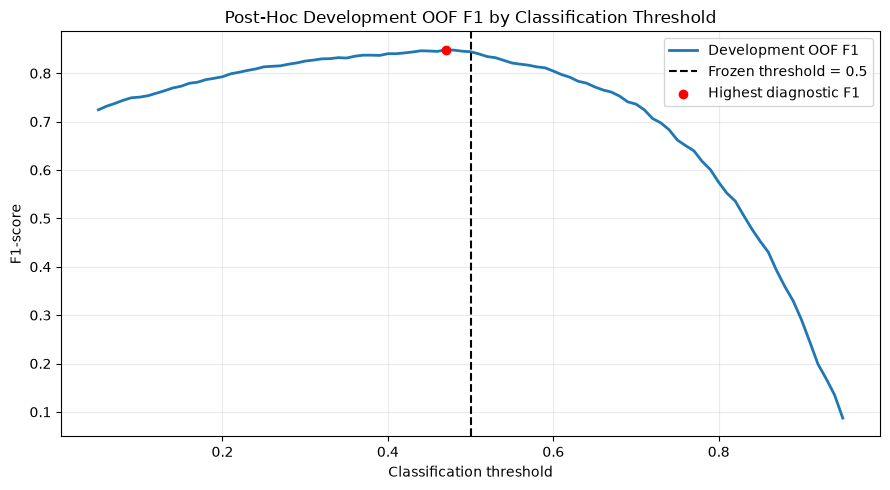

In [25]:
import numpy as np
import matplotlib.pyplot as plt

diagnostic_thresholds = np.arange(
    0.05,
    0.951,
    0.01
)

threshold_f1_scores = [
    f1_score(
        Y_dev,
        (
            selected_oof_probabilities >= threshold
        ).astype(int)
    )
    for threshold in diagnostic_thresholds
]

threshold_diagnostic = pd.DataFrame(
    {
        "threshold": diagnostic_thresholds,
        "oof_f1": threshold_f1_scores
    }
)

best_diagnostic_row = threshold_diagnostic.loc[
    threshold_diagnostic["oof_f1"].idxmax()
]

frozen_threshold_f1 = f1_score(
    Y_dev,
    (
        selected_oof_probabilities >= 0.5
    ).astype(int)
)

print(
    "Frozen threshold: 0.50"
)

print(
    f"OOF F1 at frozen threshold: "
    f"{frozen_threshold_f1:.4f}"
)

print(
    f"Highest diagnostic OOF F1: "
    f"{best_diagnostic_row['oof_f1']:.4f}"
)

print(
    f"Diagnostic threshold with highest OOF F1: "
    f"{best_diagnostic_row['threshold']:.2f}"
)

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    threshold_diagnostic["threshold"],
    threshold_diagnostic["oof_f1"],
    linewidth=2,
    label="Development OOF F1"
)

plt.axvline(
    0.5,
    color="black",
    linestyle="--",
    label="Frozen threshold = 0.5"
)

plt.scatter(
    best_diagnostic_row["threshold"],
    best_diagnostic_row["oof_f1"],
    color="red",
    zorder=3,
    label="Highest diagnostic F1"
)

plt.xlabel("Classification threshold")
plt.ylabel("F1-score")
plt.title("Post-Hoc Development OOF F1 by Classification Threshold")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

The highest diagnostic out-of-fold F1-score is 0.8485 at a threshold of 0.47, compared with 0.8445 at the frozen threshold of 0.50.

The diagnostic optimum is close to the preregistered threshold, and the difference in F1-score is only 0.0040. This indicates that the selected model's development F1-score is not highly sensitive to a small threshold adjustment around 0.5.

Because this analysis was performed post hoc and after the final evaluation had been completed, the pipeline and reported holdout results remain based on the frozen threshold of 0.5.


## Frozen Pipeline Export

The final pipeline trained exclusively on the development set is exported for use by the lightweight demonstration application. The artifact does not contain holdout observations and does not modify the frozen model, features, hyperparameters, or classification threshold.

In [26]:
from pathlib import Path
from joblib import dump

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

artifact_directory = project_root / "artifacts"
artifact_directory.mkdir(exist_ok=True)

model_artifact = {
    "pipeline": final_pipeline,
    "features": features,
    "classification_threshold": 0.5,
    "class_labels": {
        0: "catalog_false_positive",
        1: "planet"
    },
    "version": "v0.5",
    "training_observations": len(X_dev)
}

artifact_path = (
    artifact_directory
    / "exoscout_v0_5.joblib"
)

dump(
    model_artifact,
    artifact_path,
    compress=3
)

print(f"Saved artifact: {artifact_path}")
print(
    "Artifact size: "
    f"{artifact_path.stat().st_size / (1024 ** 2):.2f} MB"
)

Saved artifact: /Users/mac/Documents/Projects/exoscout/artifacts/exoscout_v0_5.joblib
Artifact size: 4.16 MB


In [27]:
from src.predict import (
    load_model_artifact,
    predict_observation
)

exported_artifact = load_model_artifact()

for position in range(3):

    observation = (
        X_holdout
        .iloc[position]
        .to_dict()
    )

    exported_result = predict_observation(
        observation,
        exported_artifact
    )

    notebook_score = float(
        holdout_planet_probabilities[position]
    )

    notebook_label = int(
        notebook_score
        >= classification_threshold
    )

    assert np.isclose(
        exported_result["planet_score"],
        notebook_score
    )

    assert (
        exported_result["predicted_label"]
        == notebook_label
    )

    print(
        f"Observation {position + 1}: "
        f"notebook_score={notebook_score:.12f}, "
        f"exported_score="
        f"{exported_result['planet_score']:.12f}, "
        f"label={notebook_label}"
    )

print(
    "Exported artifact matches notebook inference."
)

Observation 1: notebook_score=0.738638630366, exported_score=0.738638630366, label=1
Observation 2: notebook_score=0.883825090710, exported_score=0.883825090710, label=1
Observation 3: notebook_score=0.776518010630, exported_score=0.776518010630, label=1
Exported artifact matches notebook inference.
